# Computer Vision 
## Notebook 1b — SimCLR Backbone → YOLOv26-s Fine-Tune @ 20% Labels

| | |
|---|---|
| **Detector** | YOLOv26-s (frozen fair-comparison protocol — byte-identical to 2b/3b/4b) |
| **Backbone init** | **SimCLR** encoder from Notebook 1a — NT-Xent contrastive agreement between two augmented views, trained **from scratch** on the 16,483-image unlabelled pool |
| **Label budget** | **ρ = 0.20** → 4,121 labelled images via the shared `pool_rank` |
| **Baselines** | **Reused from Notebook 3b's committed output** (random-init 0.5928, COCO 0.6224 test mAP50-95 — the §4.2 run-once rule) |
| **Bonus** | Explainability grid: **EigenCAM + ScoreCAM** on the fine-tuned detector |

**Covers step :** subset builder → **weight surgery + mandatory mapping report** →
50-epoch fine-tune → val + test evaluation with PR curve → qualitative successes and
failures → the completed four-way comparison against the random-init and COCO anchors.


## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *New Notebook* → Import. Accelerator = **GPU T4 x2**; Internet =
   **On** (ultralytics install only — no COCO download needed since baselines are reused).
2. **Attach three inputs** (*Add Input*):
   - the **checkpoint dataset** carrying Notebook 1a's output —
     `simclr_yolo26s_backbone.pt`, `partB_partition.csv`, `simclr_pretrain_summary.json`;
   - **Part A Notebook 1's output** (`visiodect_yolo/`) — restores the label files;
   - the **committed Notebook 3b output** — its `partB_downstream/{random,coco,ijepa}.json`
     and `reference_100pct.json` are merged automatically (assignment §4.2: baselines run
     once, reused everywhere). `RUN_BASELINES=False` is therefore the default here.
3. **Budget**: ONE 50-epoch fine-tune —
   evaluation and the explainability bonus: **~2.5 h total**, comfortably commit-safe.
4. Fill the group fields, **Run all**, commit, set **Public**. If the four-method table shows
   SimCLR as the winner, publish `checkpoints/partB_simclr_rho20_best.pt` to the checkpoint
   dataset for the tracking notebook (§4.2 note).

## 1. CONFIG —
Architecture, checkpoint path, ρ, the shared seed, and the **frozen fair-comparison
protocol**: identical resolution, batch, epochs, optimiser/LR schedule, augmentation,
thresholds and seed for every run in every Part B notebook — only the backbone
initialisation (and, in the bonus, ρ) may vary.

In [ ]:
# =============================== CONFIG ===============================

SSL_METHOD   = "simclr"           # this run; the 4th of the four-way comparison
YOLO_ARCH    = "yolo26s.yaml"     # Part A best architecture (see justification memo)
COCO_WEIGHTS = "yolo26s.pt"       # only used if RUN_BASELINES=True (not default here)
RHO          = 0.20               # label fraction (assignment standard budget)
PARTB_SEED   = 445                # THE shared Part B seed (partition + all sampling)

# ---- frozen fair-comparison fine-tuning protocol (== Part A YOLO protocol) ----
EPOCHS, PATIENCE  = 50, 25        # assignment standard: 50 downstream epochs
IMGSZ, BATCH      = 640, 16
WORKERS           = 4
OPTIMIZER, LR0    = "auto", 0.01  # ultralytics-resolved; lr0 fallback declared
WARMUP_EPOCHS     = 3
CLOSE_MOSAIC      = 10
FLIPLR, FLIPUD, DEGREES = 0.5, 0.0, 0.0
HSV_H, HSV_S, HSV_V     = 0.015, 0.7, 0.4
MIXUP, COPY_PASTE       = 0.0, 0.0
CONF_EVAL, IOU_NMS      = 0.25, 0.7

RUN_BASELINES = False  # §4.2 run-once rule: random + COCO were trained in
                       # Notebook 3b — attach its committed output and the
                       # comparison cell merges the JSONs. Set True ONLY if the
                       # 3b output cannot be attached.
RUN_REFERENCE = False  # the 100%-label reference JSON also arrives from the
                       # attached 3b output (test mAP50-95 0.6678). Set True +
                       # attach Part A NB4's output only if 3b is unavailable.

# ---- input discovery (manual overrides take precedence) -----------------------
CKPT_MANUAL      = None   # e.g. Path(".../simclr_yolo26s_backbone.pt")
PARTITION_MANUAL = None   # e.g. Path(".../partB_partition.csv")
NB1_DIR_MANUAL   = None   # e.g. Path(".../visiodect_yolo")
PARTA_CKPT_MANUAL = None  # e.g. Path(".../checkpoints/yolov26s_best.pt")

# ---- paths --------------------------------------------------------------------
WORK_ROOT   = "/kaggle/working"
DATA_ROOT   = f"{WORK_ROOT}/partB_data"            # materialised YOLO dataset
RUN_PROJECT = f"{WORK_ROOT}/runs_partB"
SURGERY_CKPT = f"{WORK_ROOT}/simclr_surgery_init.pt"
DOWNSTREAM_DIR = f"{WORK_ROOT}/partB_downstream"   # per-run metric JSONs (reused by 1b/2b/4b)
CKPT_OUT    = f"{WORK_ROOT}/checkpoints"           # fine-tuned best.pt per init

print(f"CONFIG | {SSL_METHOD} -> {YOLO_ARCH} @ rho={RHO} | {EPOCHS} epochs, "
      f"imgsz {IMGSZ}, batch {BATCH} | seed {PARTB_SEED} | baselines={RUN_BASELINES}")


CONFIG | simclr -> yolo26s.yaml @ rho=0.2 | 50 epochs, imgsz 640, batch 16 | seed 445 | baselines=False


## 2. Environment
Only `ultralytics` is needed here — the weight surgery mirrors `ssl-detection-lab`'s own
backbone definition (`model[: len(yaml['backbone'])]`) using plain PyTorch state-dicts, so
3b stays light and version-independent.

In [2]:
%pip install -q -U ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from copy import deepcopy
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
import ultralytics

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED); torch.manual_seed(PARTB_SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 125, "font.size": 11})
for d in (DATA_ROOT, RUN_PROJECT, DOWNSTREAM_DIR, CKPT_OUT):
    Path(d).mkdir(parents=True, exist_ok=True)
print("ultralytics:", ultralytics.__version__, "| torch:", torch.__version__,
      "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.120 | torch: 2.10.0+cu128 | GPU: Tesla T4


## 3. Locate the Hand-off Artifacts
Finds the 3a checkpoint + shared partition manifest, Notebook 1's labelled images, and
(optionally) the Part A checkpoint — with loud failures naming exactly what to attach.

In [4]:
def find_file(pattern, manual, what, required=True, depth=5):
    if manual is not None:
        p = Path(manual)
        if p.exists():
            return p
        raise FileNotFoundError(f"Manual {what} path does not exist: {p}")
    base, stack = Path("/kaggle/input"), [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and c.name == pattern:
                    return c
                if c.is_dir() and dep < depth:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    if required:
        raise FileNotFoundError(f"{what} ({pattern}) not found under /kaggle/input — "
                                "attach the input listed in Section 0.")
    return None

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL)
        assert (p / "train" / "images").exists(), f"not the NB1 output: {p}"
        return p
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/).")

SSL_CKPT      = find_file("simclr_yolo26s_backbone.pt", CKPT_MANUAL, "SimCLR encoder checkpoint")
PARTITION_CSV = find_file("partB_partition.csv", PARTITION_MANUAL, "Part B partition manifest")
NB1_ROOT      = find_nb1_root()
PARTA_CKPT    = find_file("yolov26s_best.pt", PARTA_CKPT_MANUAL,
                          "Part A reference checkpoint", required=False)
summary_1a = find_file("simclr_pretrain_summary.json", None, "1a summary", required=False)
if summary_1a:
    s1a = json.loads(Path(summary_1a).read_text())
    print("1a pretraining context:", {k: s1a[k] for k in
          ("method", "epochs", "image_size", "batch_size_per_gpu", "temperature", "negatives_per_anchor", "ssl_pool_images", "best_loss", "chance_loss", "train_minutes", "partition_fingerprint") if k in s1a})
print("SimCLR encoder :", SSL_CKPT)
print("Partition CSV  :", PARTITION_CSV)
print("NB1 labels root:", NB1_ROOT)
print("Part A ckpt    :", PARTA_CKPT or "not attached (reference section will skip)")


# ---- cross-notebook protocol check: the partition must be the SAME split ------
import hashlib
_part = pd.read_csv(PARTITION_CSV)
_FP = hashlib.md5("|".join(f"{r.filename}:{r.partition}" for r in
                           _part.sort_values("filename").itertuples()).encode()).hexdigest()[:16]
print(f"\n[checksum] partition fingerprint = {_FP}")
if summary_1a:
    _fp_1a = s1a.get("partition_fingerprint")
    if _fp_1a:
        ok = (_fp_1a == _FP)
        print(f"[checksum] 1a pretraining fingerprint = {_fp_1a} -> "
              f"{'MATCH' if ok else 'MISMATCH'}")
        assert ok, ("1a pretrained on a DIFFERENT partition than this notebook is fine-tuning "
                    "on. The SimCLR encoder may have seen these test images during "
                    "pretraining (leakage case i). Stop and reconcile before training.")
print("[OK] this notebook fine-tunes on the same split every other Part B notebook used")


1a pretraining context: {'method': 'simclr', 'epochs': 35, 'image_size': 224, 'batch_size_per_gpu': 128, 'temperature': 0.2, 'negatives_per_anchor': 254, 'ssl_pool_images': 16483, 'best_loss': 1.7582003939896822, 'chance_loss': 5.5413, 'train_minutes': 168.8, 'partition_fingerprint': '75e9c05d747bd9ec'}
SimCLR encoder : /kaggle/input/notebooks/mahmudurrahman00627/grouph-partb-01a-simclr-pretrain/simclr_yolo26s_backbone.pt
Partition CSV  : /kaggle/input/notebooks/mahmudurrahman00627/grouph-partb-01a-simclr-pretrain/partB_partition.csv
NB1 labels root: /kaggle/input/notebooks/mahmudurrahman00627/cse445notebook1-eda-n1/visiodect_yolo
Part A ckpt    : /kaggle/input/notebooks/ahnafahmed11/cse445notebook4-yolov26trainevaluate-erroranalysis/checkpoints/yolov26s_best.pt

[checksum] partition fingerprint = 75e9c05d747bd9ec
[checksum] 1a pretraining fingerprint = 75e9c05d747bd9ec -> MATCH
[OK] this notebook fine-tunes on the same split every other Part B notebook used


## 4. Subset Builder —
Rebuilds **D₀.₂** from the shared manifest's `pool_rank` (`rank < 0.20·N` — nested by
construction with the bonus budgets), restores the annotations from Notebook 1, prints
**image and instance counts**, and re-verifies **disjointness against test and validation**
by filename intersection. The materialised YOLO dataset uses the partition's val/test —
never Part A's splits.

In [5]:
partition = pd.read_csv(PARTITION_CSV)
N = len(partition)
n20 = round(RHO * N)
sub = {
    "train": partition[(partition.partition == "ssl_pool") & (partition.pool_rank < n20)],
    "val":   partition[partition.partition == "val"],
    "test":  partition[partition.partition == "test"],
}
print(f"Partition manifest: {N:,} images | rho={RHO} -> {n20:,} labelled fine-tune images "
      f"(pool_rank < {n20:,})")

# mandated disjointness re-verification in THIS notebook
tr, va, te = (set(sub[k].filename) for k in ("train", "val", "test"))
assert not (tr & va) and not (tr & te) and not (va & te)
assert len(tr) == n20
print("[OK] Disjointness verified by filename intersection: "
      "train20 ∩ val = 0, train20 ∩ test = 0, val ∩ test = 0")

CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]

def label_path_for(img_path):
    return Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")

def safe_link(src, dst):
    if dst.exists():
        return
    try:
        os.symlink(src, dst)
    except OSError:
        shutil.copy2(src, dst)

data_root = Path(DATA_ROOT)
if data_root.exists():
    shutil.rmtree(data_root)
counts = []
for split, frame in sub.items():
    (data_root / split / "images").mkdir(parents=True)
    (data_root / split / "labels").mkdir(parents=True)
    inst = 0
    for _, r in tqdm(frame.iterrows(), total=len(frame), desc=f"materialising {split}"):
        img = Path(r.source_path); lbl = label_path_for(img)
        assert lbl.exists(), f"missing label for {img.name} — wrong NB1 output attached?"
        safe_link(img, data_root / split / "images" / img.name)
        safe_link(lbl, data_root / split / "labels" / lbl.name)
        inst += sum(1 for ln in lbl.read_text().splitlines() if len(ln.split()) == 5)
    counts.append({"split": split, "images": len(frame), "instances": inst})
count_df = pd.DataFrame(counts)
display(count_df)

# per-class instance counts in the 20% subset (assignment: instance counts)
per_cls = {c: 0 for c in CLASS_NAMES}
for _, r in sub["train"].iterrows():
    for ln in label_path_for(Path(r.source_path)).read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            per_cls[CLASS_NAMES[int(t[0])]] += 1
print("20%-subset instances per class:", per_cls)

DATA_YAML = data_root / "data.yaml"
DATA_YAML.write_text(f"path: {data_root}\ntrain: train/images\nval: val/images\n"
                     f"test: test/images\nnc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
print("data.yaml written ->", DATA_YAML)


Partition manifest: 20,603 images | rho=0.2 -> 4,121 labelled fine-tune images (pool_rank < 4,121)
[OK] Disjointness verified by filename intersection: train20 ∩ val = 0, train20 ∩ test = 0, val ∩ test = 0


materialising train:   0%|          | 0/4121 [00:00<?, ?it/s]

materialising val:   0%|          | 0/2060 [00:00<?, ?it/s]

materialising test:   0%|          | 0/2060 [00:00<?, ?it/s]

,split,images,instances
0,train,4121,4122
1,val,2060,2060
2,test,2060,2060


20%-subset instances per class: {'Anafi': 683, 'DJI_FPV': 694, 'DJI_Phantom': 662, 'EFT_E410S': 669, 'Mavic_Air': 704, 'Mavic_Enterprise': 710}
data.yaml written -> /kaggle/working/partB_data/data.yaml


## 5. Weight Surgery + Mandatory Layer-Mapping Report —
Identical boundary to 2b/3b/4b: the pretrained encoder is
**`model[: len(yaml["backbone"])]`**, exactly how `ssl-detection-lab`'s
`YOLOBackboneEncoder` defines it, so the same modules carry SSL weights in every arm of the
comparison.

The 1a checkpoint is the package's exported YOLO student — same `yolo26s` architecture, so
its keys match a fresh model one-to-one (the assertion below fails loudly if not). Only the
backbone-module keys carry SimCLR's contrastive representation; the fresh model contributes
a new random neck and Detect head.

**The projection head is not here, and that is the point.** 1a trained a
`512 → 1024 → 256` MLP on top of the pooled backbone features and it is discarded at export.
The head is optimised to be *invariant* to SimCLR's augmentations — colour jitter, greyscale,
scale — and a drone detector needs precisely those cues to localise a small object. The
backbone one layer earlier retains them. This is viva §4.3 Q3, and the mapping report below
is the evidence that only the backbone transferred.

In [6]:
ssl_yolo   = YOLO(str(SSL_CKPT))            # 1a export: distilled backbone + lightly-init rest
fresh_yolo = YOLO(YOLO_ARCH)                # brand-new model: fresh random neck/head
BACKBONE_END = len(fresh_yolo.model.yaml["backbone"])   # == ssldet's boundary

ssl_sd, fresh_sd = ssl_yolo.model.state_dict(), fresh_yolo.model.state_dict()
assert set(ssl_sd) == set(fresh_sd), "architecture mismatch between the 1a checkpoint and yaml!"

merged, n_ssl_params = {}, 0
for k, v in fresh_sd.items():
    idx = int(k.split(".")[1]) if k.startswith("model.") else -1
    from_ssl = 0 <= idx < BACKBONE_END
    merged[k] = ssl_sd[k].clone() if from_ssl else v
    if from_ssl:
        n_ssl_params += v.numel()
fresh_yolo.model.load_state_dict(merged, strict=True)

# ---- the mandatory mapping report -------------------------------------------
rows = []
for i, m in enumerate(fresh_yolo.model.model):
    rows.append({"module": f"model.{i}", "layer": type(m).__name__,
                 "params": sum(p.numel() for p in m.parameters()),
                 "initialised from": "SimCLR (NT-Xent, 1a)" if i < BACKBONE_END
                                     else "random (fresh)"})
mapping = pd.DataFrame(rows)
display(mapping)
total = sum(r["params"] for r in rows)
print(f"Backbone boundary: modules 0..{BACKBONE_END-1} (len(yaml['backbone']) — identical "
      f"to ssl-detection-lab's YOLOBackboneEncoder)")
print(f"SSL-initialised parameters: {n_ssl_params/1e6:.2f} M of {total/1e6:.2f} M "
      f"({n_ssl_params/total:.1%}); neck + Detect head remain randomly initialised.")

# ---- save in ultralytics checkpoint format and PROVE the weights survive -----
torch.save({"model": deepcopy(fresh_yolo.model), "train_args": {}}, SURGERY_CKPT)
reloaded = YOLO(SURGERY_CKPT)
bb_key  = next(k for k in ssl_sd if k.startswith("model.0.") and ssl_sd[k].ndim > 1)
hd_key  = next(k for k in fresh_sd
               if k.startswith(f"model.{len(fresh_yolo.model.model)-1}.") and fresh_sd[k].ndim > 1)
r_sd = reloaded.model.state_dict()
print("proof — backbone tensor equals SimCLR encoder :",
      bool(torch.equal(r_sd[bb_key].float(), ssl_sd[bb_key].float())))
print("proof — head tensor equals fresh random init  :",
      bool(torch.equal(r_sd[hd_key].float(), fresh_sd[hd_key].float())))
del ssl_yolo, fresh_yolo, reloaded, merged, ssl_sd, fresh_sd
torch.cuda.empty_cache()


,module,layer,params,initialised from
0,model.0,Conv,928,"SimCLR (NT-Xent, 1a)"
1,model.1,Conv,18560,"SimCLR (NT-Xent, 1a)"
2,model.2,C3k2,26080,"SimCLR (NT-Xent, 1a)"
3,model.3,Conv,147712,"SimCLR (NT-Xent, 1a)"
4,model.4,C3k2,103360,"SimCLR (NT-Xent, 1a)"
5,model.5,Conv,590336,"SimCLR (NT-Xent, 1a)"
6,model.6,C3k2,346112,"SimCLR (NT-Xent, 1a)"
7,model.7,Conv,1180672,"SimCLR (NT-Xent, 1a)"
8,model.8,C3k2,1380352,"SimCLR (NT-Xent, 1a)"
9,model.9,SPPF,656896,"SimCLR (NT-Xent, 1a)"


Backbone boundary: modules 0..10 (len(yaml['backbone']) — identical to ssl-detection-lab's YOLOBackboneEncoder)
SSL-initialised parameters: 5.46 M of 10.01 M (54.5%); neck + Detect head remain randomly initialised.
proof — backbone tensor equals SimCLR encoder : True
proof — head tensor equals fresh random init  : True


## 6. Fine-Tuning Runs — 
One helper enforces the **frozen protocol** for every run — the only argument that differs
is the initialisation. Budget note (measured, Part A): YOLOv26-s = 322.6 min / 50 epochs /
14,422 images → ≈ 92 min per run at 4,121 images → ≈ 4.6 h for all three.

In [7]:
def finetune_and_eval(init_name, weights):
    """Train with the frozen protocol from `weights`; return metrics record."""
    run_name = f"{init_name}_rho{int(RHO*100)}"
    t0 = time.time()
    model = YOLO(weights)
    model.train(data=str(DATA_YAML), epochs=EPOCHS, patience=PATIENCE, imgsz=IMGSZ,
                batch=BATCH, workers=WORKERS, device=DEVICE, seed=PARTB_SEED,
                project=RUN_PROJECT, name=run_name, exist_ok=True,
                optimizer=OPTIMIZER, lr0=LR0, warmup_epochs=WARMUP_EPOCHS,
                close_mosaic=CLOSE_MOSAIC, fliplr=FLIPLR, flipud=FLIPUD, degrees=DEGREES,
                hsv_h=HSV_H, hsv_s=HSV_S, hsv_v=HSV_V, mixup=MIXUP, copy_paste=COPY_PASTE,
                plots=True, verbose=False)
    minutes = (time.time() - t0) / 60
    run_dir = Path(RUN_PROJECT) / run_name
    best = run_dir / "weights" / "best.pt"
    best = best if best.exists() else run_dir / "weights" / "last.pt"
    ckpt_out = Path(CKPT_OUT) / f"partB_{init_name}_rho{int(RHO*100)}_best.pt"
    shutil.copy2(best, ckpt_out)

    model = YOLO(str(best))
    rec = {"init": init_name, "rho": RHO, "epochs": EPOCHS,
           "train_minutes": round(minutes, 1)}
    for split in ("val", "test"):
        m = model.val(data=str(DATA_YAML), split=split, imgsz=IMGSZ, batch=BATCH,
                      conf=0.001, iou=IOU_NMS, device=DEVICE, plots=(split == "test"),
                      project=f"{WORK_ROOT}/evaluation", name=f"{run_name}_{split}",
                      exist_ok=True, verbose=False)
        rec |= {f"{split}_precision": round(float(m.box.mp), 4),
                f"{split}_recall":    round(float(m.box.mr), 4),
                f"{split}_mAP50":     round(float(m.box.map50), 4),
                f"{split}_mAP50_95":  round(float(m.box.map), 4)}
    try:  # best epoch from results.csv
        res = pd.read_csv(run_dir / "results.csv"); res.columns = [c.strip() for c in res.columns]
        rec["best_epoch"] = int(res.loc[res["metrics/mAP50-95(B)"].idxmax(), "epoch"])
    except Exception:
        rec["best_epoch"] = None
    rec["checkpoint"] = str(ckpt_out)
    Path(DOWNSTREAM_DIR, f"{init_name}.json").write_text(json.dumps(rec, indent=2))
    print(f"[{init_name}] {minutes:.0f} min | test mAP50-95 {rec['test_mAP50_95']} "
          f"| best epoch {rec['best_epoch']} | saved {ckpt_out.name}")
    torch.cuda.empty_cache()
    return rec

results = {}
results["simclr"] = finetune_and_eval("simclr", SURGERY_CKPT)


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/partB_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/simclr_surgery_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

### 6.1 Demo inference on one validation image 
*(The full evaluation above ran as part of the helper; this cell shows the mandated
single-image sanity check with the fine-tuned SimCLR detector.)*

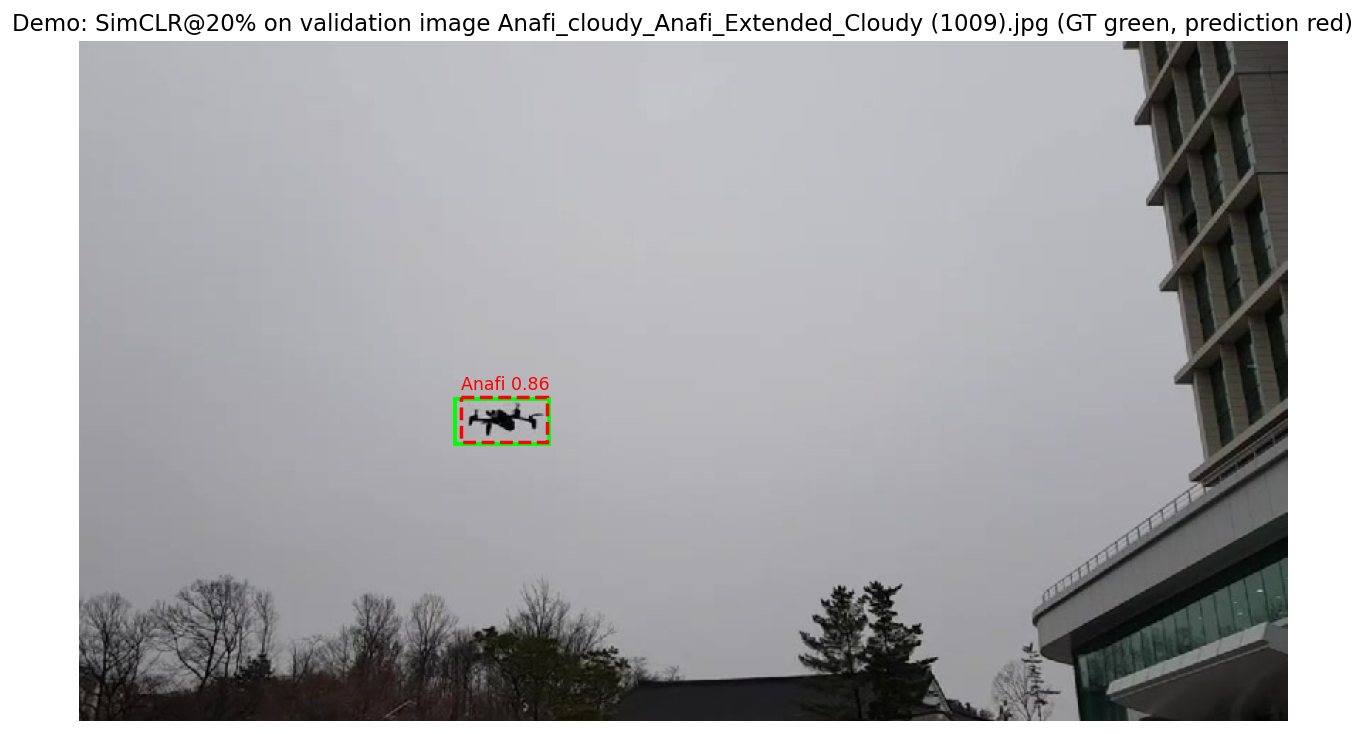

In [8]:
simclr_best = YOLO(results["simclr"]["checkpoint"])
demo_img = sorted((Path(DATA_ROOT) / "val" / "images").iterdir())[0]
res = simclr_best.predict(str(demo_img), imgsz=IMGSZ, conf=CONF_EVAL, device=DEVICE,
                         verbose=False)[0]
im = np.array(Image.open(demo_img).convert("RGB")); H, W = im.shape[:2]
fig, ax = plt.subplots(figsize=(10, 6)); ax.imshow(im); ax.set_axis_off()
lbl = Path(str(demo_img).replace("/images/", "/labels/")).with_suffix(".txt")
for ln in lbl.read_text().splitlines():
    c, cx, cy, w, h = map(float, ln.split())
    ax.add_patch(mpatches.Rectangle(((cx-w/2)*W, (cy-h/2)*H), w*W, h*H,
                                    fill=False, edgecolor="lime", lw=2.2))
if res.boxes is not None:
    for b, c, s in zip(res.boxes.xyxy.cpu().numpy(),
                       res.boxes.cls.cpu().numpy().astype(int),
                       res.boxes.conf.cpu().numpy()):
        ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                                        fill=False, edgecolor="red", lw=2, linestyle="--"))
        ax.text(b[0], b[1]-5, f"{CLASS_NAMES[int(c)]} {s:.2f}", color="red", fontsize=10)
ax.set_title(f"Demo: SimCLR@20% on validation image {demo_img.name} "
             "(GT green, prediction red)")
plt.tight_layout(); plt.show()


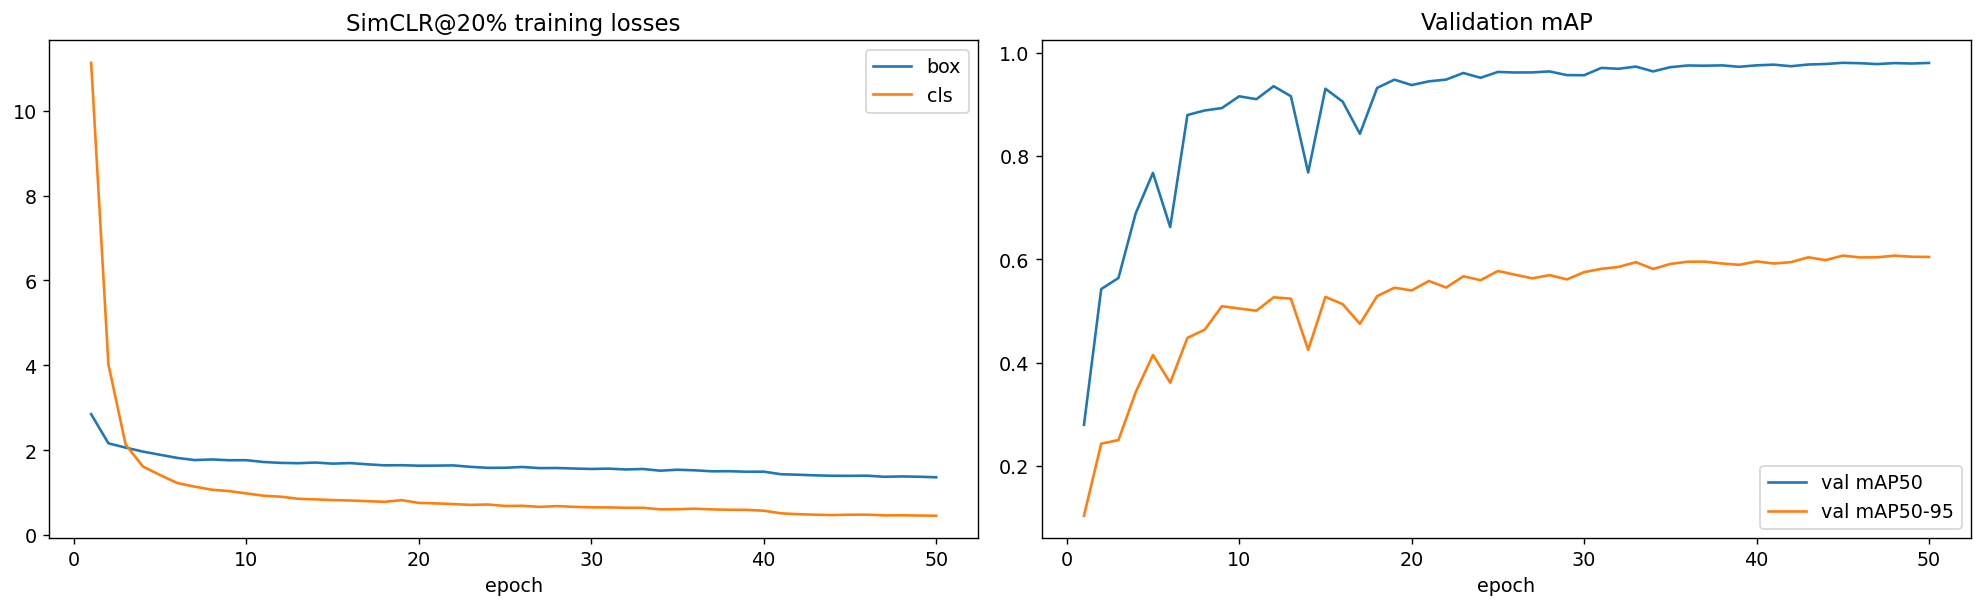

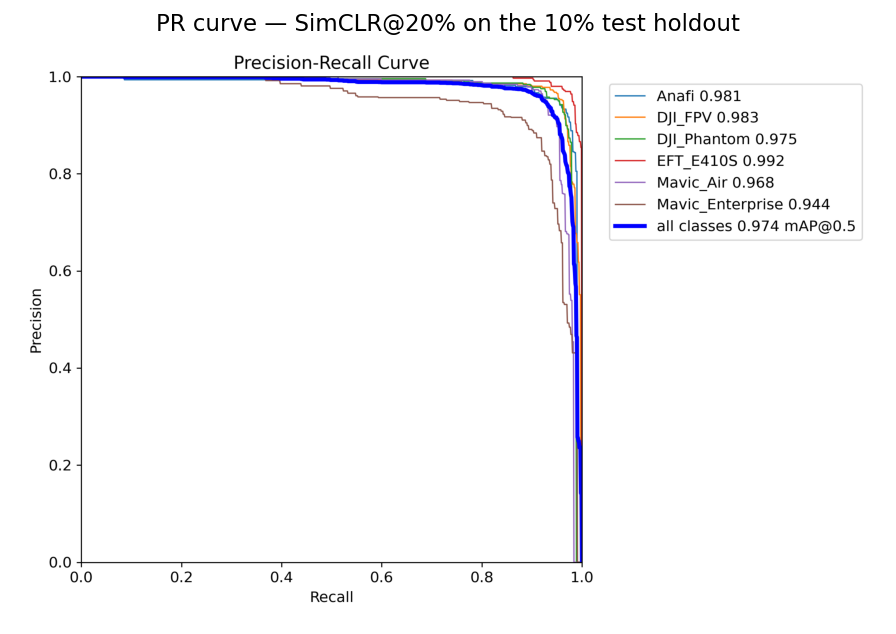

In [9]:
# ---- training curves + PR curve for the SimCLR run ---------------------------
run_dir = Path(RUN_PROJECT) / f"simclr_rho{int(RHO*100)}"
res = pd.read_csv(run_dir / "results.csv"); res.columns = [c.strip() for c in res.columns]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for k, lab in [("train/box_loss", "box"), ("train/cls_loss", "cls"), ("train/dfl_loss", "dfl")]:
    if k in res: ax[0].plot(res.epoch, res[k], label=lab)
ax[0].set_title("SimCLR@20% training losses"); ax[0].set_xlabel("epoch"); ax[0].legend()
for k, lab in [("metrics/mAP50(B)", "val mAP50"), ("metrics/mAP50-95(B)", "val mAP50-95")]:
    if k in res: ax[1].plot(res.epoch, res[k], label=lab)
ax[1].set_title("Validation mAP"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{WORK_ROOT}/simclr20_curves.png", dpi=150,
                                bbox_inches="tight"); plt.show()

for cand in ["BoxPR_curve.png", "PR_curve.png"]:
    p = Path(f"{WORK_ROOT}/evaluation") / f"simclr_rho{int(RHO*100)}_test" / cand
    if p.exists():
        plt.figure(figsize=(9, 7)); plt.imshow(plt.imread(p)); plt.axis("off")
        plt.title("PR curve — SimCLR@20% on the 10% test holdout"); plt.show()
        break


## 7. Baselines — Reused from Notebook 3b 
Random-init and COCO anchors (and I-JEPA itself) were trained once in Notebook 3b under the
byte-identical protocol; attaching its committed output delivers their JSONs to Section 8.
`RUN_BASELINES=True` re-trains them here only as a fallback.

In [10]:
if RUN_BASELINES:
    results["random"] = finetune_and_eval("random", YOLO_ARCH)
    results["coco"]   = finetune_and_eval("coco",   COCO_WEIGHTS)
else:
    print("RUN_BASELINES=False — baseline JSONs are expected from an attached "
          "notebook output and will be merged in Section 8.")


RUN_BASELINES=False — baseline JSONs are expected from an attached notebook output and will be merged in Section 8.


## 8. Optional — the 100%-Label Part A Reference 
If Part A's YOLOv26-s checkpoint is attached, it is re-evaluated on the **new 10% test
holdout** to give the upper reference line for every Part B plot. The assignment's caveat is
printed with it: this reference is **optimistic**, because some holdout images were inside
Part A's training split.

In [11]:
if RUN_REFERENCE and PARTA_CKPT is not None:
    m = YOLO(str(PARTA_CKPT)).val(data=str(DATA_YAML), split="test", imgsz=IMGSZ,
                                  batch=BATCH, conf=0.001, iou=IOU_NMS, device=DEVICE,
                                  plots=False, project=f"{WORK_ROOT}/evaluation",
                                  name="reference_100pct_test", exist_ok=True, verbose=False)
    ref = {"init": "partA_reference_100pct_labels",
           "test_precision": round(float(m.box.mp), 4),
           "test_recall": round(float(m.box.mr), 4),
           "test_mAP50": round(float(m.box.map50), 4),
           "test_mAP50_95": round(float(m.box.map), 4),
           "caveat": "optimistic — some of this holdout was in Part A's training split"}
    Path(DOWNSTREAM_DIR, "reference_100pct.json").write_text(json.dumps(ref, indent=2))
    print(json.dumps(ref, indent=2))
else:
    print("Part A checkpoint not attached — reference skipped (attach Notebook 4's "
          "output to enable; required for the report's dashed reference line).")


Part A checkpoint not attached — reference skipped (attach Notebook 4's output to enable; required for the report's dashed reference line).


## 9. Comparison — the completed four-way table at ρ = 0.20
This notebook closes the comparison. Merging every `partB_downstream/*.json` in the session
plus the attached outputs gives all six initialisations: **SimCLR, BYOL, I-JEPA, DINOv3,
random-init, COCO**, against the optimistic 100%-label reference (**0.6678**).

Reference numbers already on the board from the committed runs: random **0.5928**,
I-JEPA **0.6085**, COCO **0.6224**, DINOv3 **0.6083**.

Two footnotes print with the table, and both belong in the report:

1. **DINOv3 fairness footnote** — DINOv3 is domain-adaptive from *released* LVD-1689M
   weights; SimCLR, BYOL and I-JEPA train from scratch on the pool alone. Any DINOv3
   advantage partly reflects inherited web-scale pretraining, not the SSL objective.
2. **SimCLR compute footnote** — 254 negatives per anchor against the paper's 8190, from
   scratch on 16k images. If SimCLR trails, the mechanism is available and testable; do not
   report it as "contrastive learning does not work here".

The **ranking printed at the bottom selects the Task-1 winner**, which is the detector
Notebook 5 deploys for tracking and the initialisation the bonus ablation sweeps.

In [12]:
recs = {}
for j in list(Path(DOWNSTREAM_DIR).glob("*.json")):
    recs[j.stem] = json.loads(j.read_text())
stack = [(Path("/kaggle/input"), 0)]
while stack:
    d, dep = stack.pop()
    try:
        for c in d.iterdir():
            if c.is_file() and c.parent.name == "partB_downstream" and c.suffix == ".json":
                recs.setdefault(c.stem, json.loads(c.read_text()))
            elif c.is_dir() and dep < 5:
                stack.append((c, dep + 1))
    except (PermissionError, OSError):
        pass

comp = pd.DataFrame([r for k, r in recs.items() if k != "reference_100pct"])
cols = [c for c in ["init", "rho", "val_mAP50_95", "test_mAP50", "test_mAP50_95",
                    "test_precision", "test_recall", "best_epoch", "train_minutes"] if c in comp]
comp = comp[cols].sort_values("test_mAP50_95", ascending=False).reset_index(drop=True)
display(comp)

get = lambda n, k="test_mAP50_95": next((r[k] for r in recs.values() if r["init"] == n), None)
sc, rd, co = get("simclr"), get("random"), get("coco")
ij, by, dv = get("ijepa"), get("byol"), get("dinov3")
ref = recs.get("reference_100pct", {}).get("test_mAP50_95")
if sc is not None and rd is not None:
    print(f"SimCLR vs random init : {sc - rd:+.4f} mAP50-95  <- value of contrastive pretraining at 20% labels")
if sc is not None and co is not None:
    print(f"SimCLR vs COCO init   : {sc - co:+.4f} mAP50-95  <- in-domain contrastive SSL vs supervised COCO transfer")
if sc is not None and ij is not None:
    print(f"SimCLR vs I-JEPA      : {sc - ij:+.4f} mAP50-95  <- contrastive vs latent-prediction, both from scratch")
if sc is not None and by is not None:
    print(f"SimCLR vs BYOL        : {sc - by:+.4f} mAP50-95  <- negatives vs negative-free self-distillation")
if sc is not None and dv is not None:
    print(f"SimCLR vs DINOv3      : {sc - dv:+.4f} mAP50-95  <- from-scratch vs domain-adapted released weights")
if sc is not None and ref:
    print(f"SimCLR@20% recovers {sc/ref:.1%} of the (optimistic) 100%-label Part A reference "
          f"({sc:.4f} / {ref:.4f})")
print("\nFAIRNESS FOOTNOTE (mandatory in the report): DINOv3 starts from RELEASED "
      "LVD-1689M weights and is domain-adapted on our pool; SimCLR/BYOL/I-JEPA train from "
      "scratch on the pool alone. Any DINOv3 advantage partly reflects inherited web-scale "
      "pretraining, not the SSL objective alone.")
print("\nSIMCLR COMPUTE FOOTNOTE: 1a ran batch 128/process = 254 negatives per anchor "
      "(paper: 4096 -> 8190) for 50 epochs on 16,483 images. NT-Xent is negative-count "
      "limited, so this is the single largest handicap in the comparison and the "
      "mechanistic explanation for a weak SimCLR result -- see report S6.")

# ---- Task-1 winner: the detector Notebook 5 deploys and the bonus sweeps ------
ssl_only = {k: v for k, v in {"simclr": sc, "byol": by, "ijepa": ij, "dinov3": dv}.items()
            if v is not None}
if ssl_only:
    ranked = sorted(ssl_only.items(), key=lambda kv: -kv[1])
    print("\nSSL RANKING at rho=0.20 by test mAP50-95 (assignment S4.2 'Selecting the Best "
          "SSL Backbone' -- this table must appear in the report):")
    for r_, (k, v) in enumerate(ranked, 1):
        print(f"  {r_}. {k:8s} {v:.4f}")
    winner = ranked[0][0]
    print(f"\n>>> TASK-1 WINNER: {winner} ({ranked[0][1]:.4f})")
    print("    -> export this checkpoint for Notebook 5 (tracking) and confirm the bonus "
          "ablation swept THIS initialisation.")
    if len(ssl_only) < 4:
        print(f"    [!] only {len(ssl_only)}/4 SSL methods present -- attach the missing "
              "downstream outputs before treating this ranking as final.")


,init,rho,val_mAP50_95,test_mAP50,test_mAP50_95,test_precision,test_recall,best_epoch,train_minutes
0,coco,0.2,0.6217,0.9839,0.6224,0.9698,0.9731,36,80.2
1,ijepa,0.2,0.6048,0.9737,0.6085,0.9296,0.9350,47,78.6
2,simclr,0.2,0.6068,0.9738,0.6041,0.9462,0.9362,45,84.0
3,random,0.2,0.5960,0.9559,0.5928,0.9197,0.9012,49,77.5


SimCLR vs random init : +0.0113 mAP50-95  <- value of contrastive pretraining at 20% labels
SimCLR vs COCO init   : -0.0183 mAP50-95  <- in-domain contrastive SSL vs supervised COCO transfer
SimCLR vs I-JEPA      : -0.0044 mAP50-95  <- contrastive vs latent-prediction, both from scratch
SimCLR@20% recovers 90.5% of the (optimistic) 100%-label Part A reference (0.6041 / 0.6678)

FAIRNESS FOOTNOTE (mandatory in the report): DINOv3 starts from RELEASED LVD-1689M weights and is domain-adapted on our pool; SimCLR/BYOL/I-JEPA train from scratch on the pool alone. Any DINOv3 advantage partly reflects inherited web-scale pretraining, not the SSL objective alone.

SIMCLR COMPUTE FOOTNOTE: 1a ran batch 128/process = 254 negatives per anchor (paper: 4096 -> 8190) for 50 epochs on 16,483 images. NT-Xent is negative-count limited, so this is the single largest handicap in the comparison and the mechanistic explanation for a weak SimCLR result -- see report S6.

SSL RANKING at rho=0.20 by test mAP50

## 10. Qualitative Predictions — 6–8 Successes and Failures
A full test-split sweep with the SimCLR@20% detector (predictions keyed by **input**
filename — ultralytics rewrites `res.path` for list sources), greedily matched at IoU 0.5,
then a panel of 4 successes + 4 failures with **full frame and 3× zoom** (Part A style —
drones are ~59 px in 2400×1080 frames). The per-scenario miss rates print alongside, so the
report can test whether the Part A failure signature (evening / Mavic_Enterprise / small)
survives the 20% budget.

In [13]:
def iou_xyxy(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

def gt_for(img_path):
    lbl = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
    with Image.open(img_path) as im:
        W, H = im.size
    out = []
    for ln in lbl.read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            c, cx, cy, w, h = int(t[0]), *map(float, t[1:])
            out.append({"cls": c, "box": [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H]})
    return out

def parse_stem(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            return c, stem[len(c)+1:].split("_")[0]
    return "unknown", "unknown"

test_imgs = sorted(str(p) for p in (Path(DATA_ROOT) / "test" / "images").iterdir())
pred_cache, CHUNK = {}, 32
for i in tqdm(range(0, len(test_imgs), CHUNK), desc="SimCLR@20% test sweep"):
    chunk = test_imgs[i:i+CHUNK]
    for src, r in zip(chunk, simclr_best.predict(chunk, imgsz=IMGSZ, conf=CONF_EVAL,
                                                iou=IOU_NMS, device=DEVICE, verbose=False)):
        preds = []
        if r.boxes is not None:
            for b, c, s in zip(r.boxes.xyxy.cpu().numpy(),
                               r.boxes.cls.cpu().numpy().astype(int),
                               r.boxes.conf.cpu().numpy()):
                preds.append({"cls": int(c), "box": b.tolist(), "score": float(s)})
        pred_cache[Path(src).name] = preds

rows = []
for img in test_imgs:
    gt, preds = gt_for(img), pred_cache[Path(img).name]
    used, tp = set(), 0
    for pr in sorted(preds, key=lambda p: -p["score"]):
        best_i, best_g = 0, None
        for gi, g in enumerate(gt):
            if gi in used or g["cls"] != pr["cls"]:
                continue
            i_ = iou_xyxy(pr["box"], g["box"])
            if i_ > best_i:
                best_i, best_g = i_, gi
        if best_g is not None and best_i >= 0.5:
            used.add(best_g); tp += 1
    cname, scen = parse_stem(Path(img).stem)
    rows.append({"image": img, "class_name": cname, "scenario": scen,
                 "fn": len(gt) - tp, "fp": len(preds) - tp,
                 "side": (gt[0]["box"][2]-gt[0]["box"][0]) if gt else np.nan})
err = pd.DataFrame(rows)
err.to_csv(f"{WORK_ROOT}/simclr20_test_errors.csv", index=False)
print(f"FN frames: {(err.fn>0).sum()} ({(err.fn>0).mean():.2%}) | FP boxes: {err.fp.sum()}")
print("FN rate by scenario:", err.groupby("scenario").fn.mean().round(4).to_dict(),
      " (Part A signature: evening worst)")


SimCLR@20% test sweep:   0%|          | 0/65 [00:00<?, ?it/s]

FN frames: 89 (4.32%) | FP boxes: 316
FN rate by scenario: {'cloudy': 0.0163, 'evening': 0.0615, 'sunny': 0.0506}  (Part A signature: evening worst)


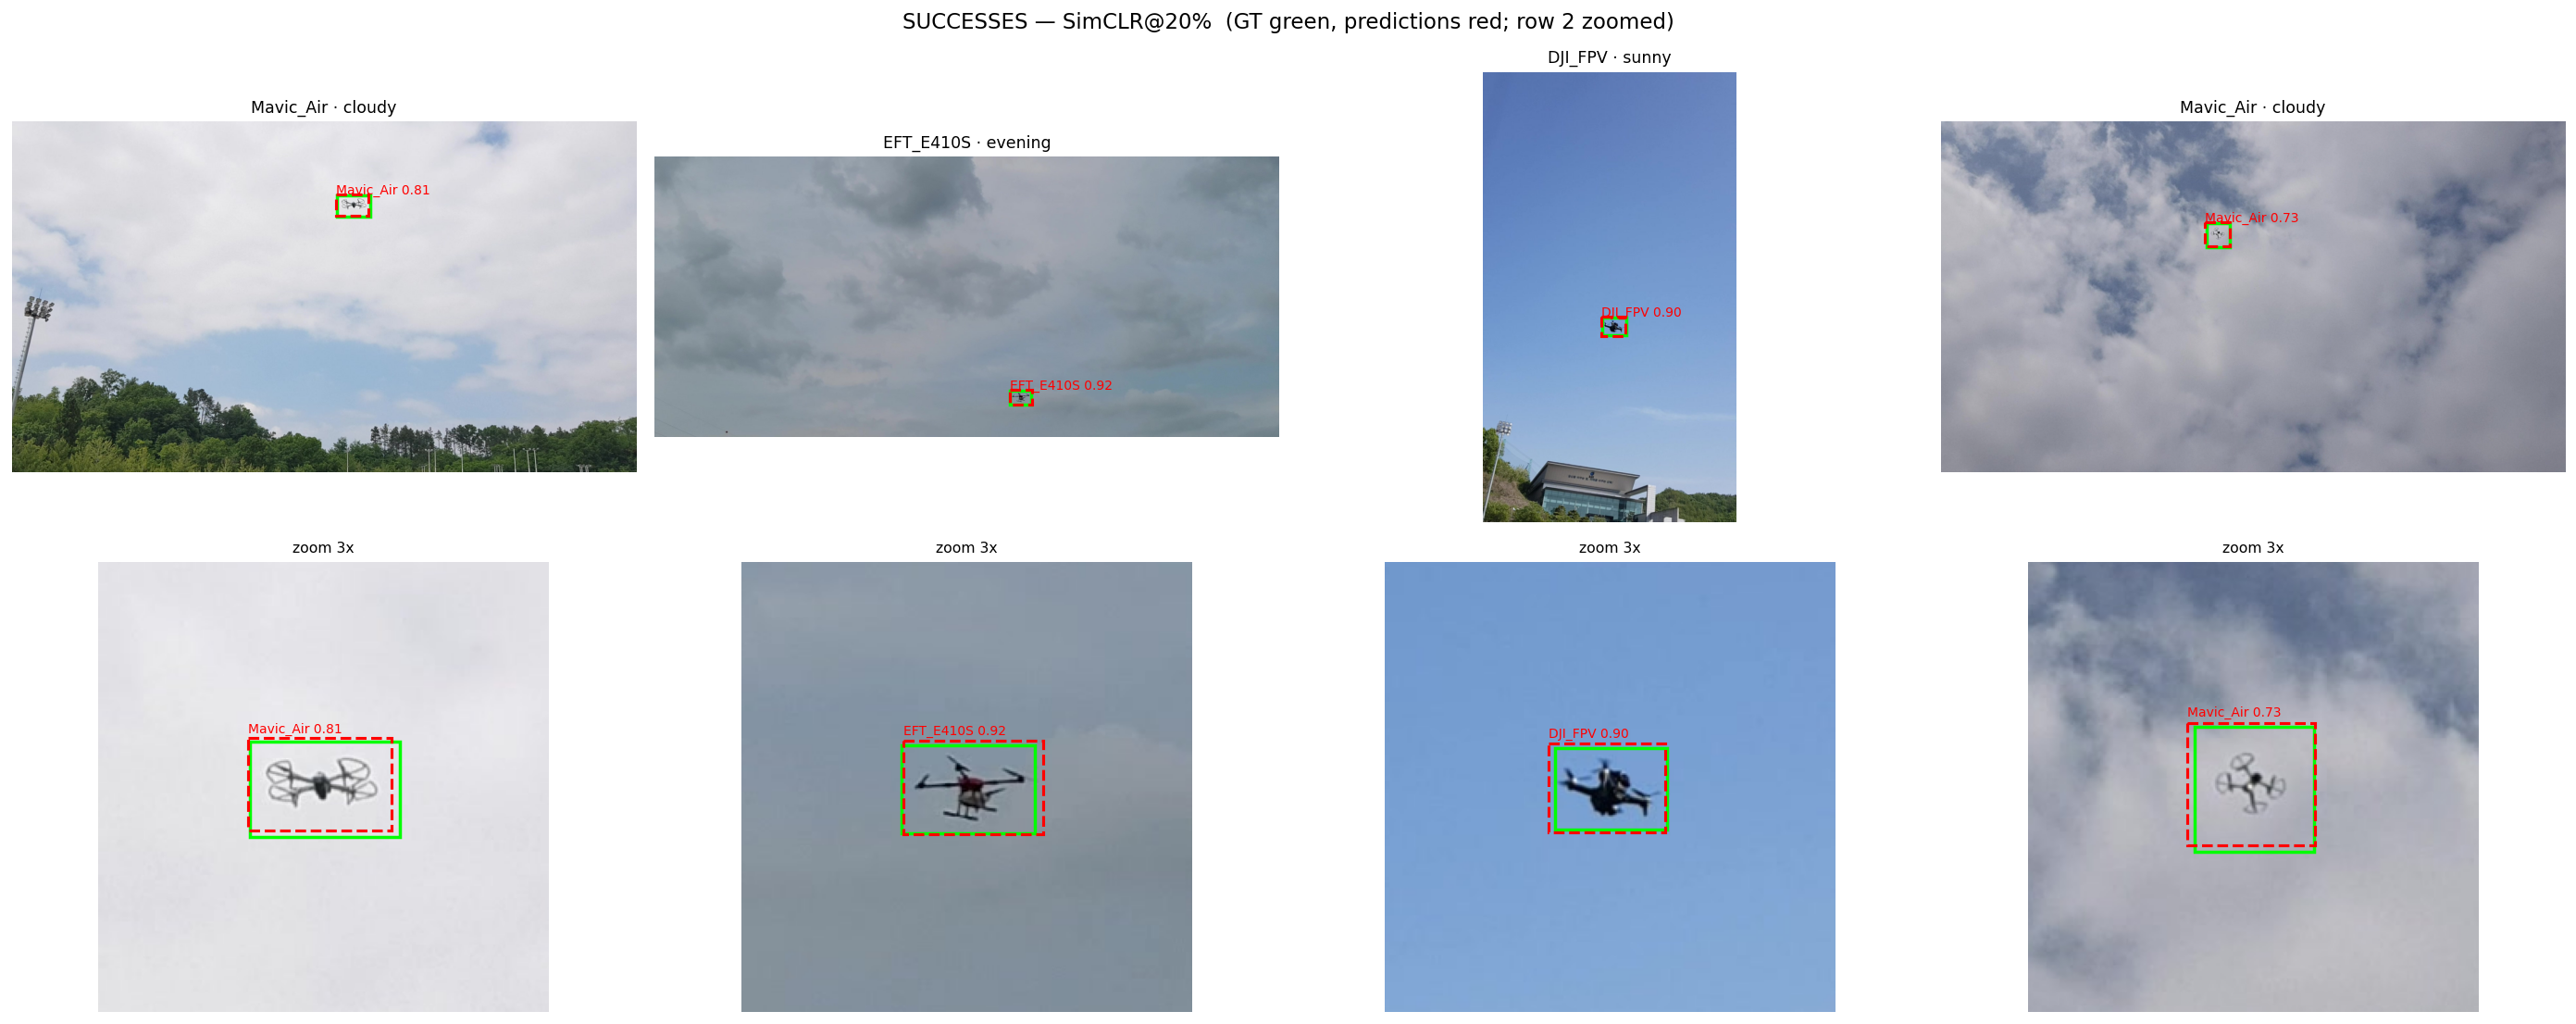

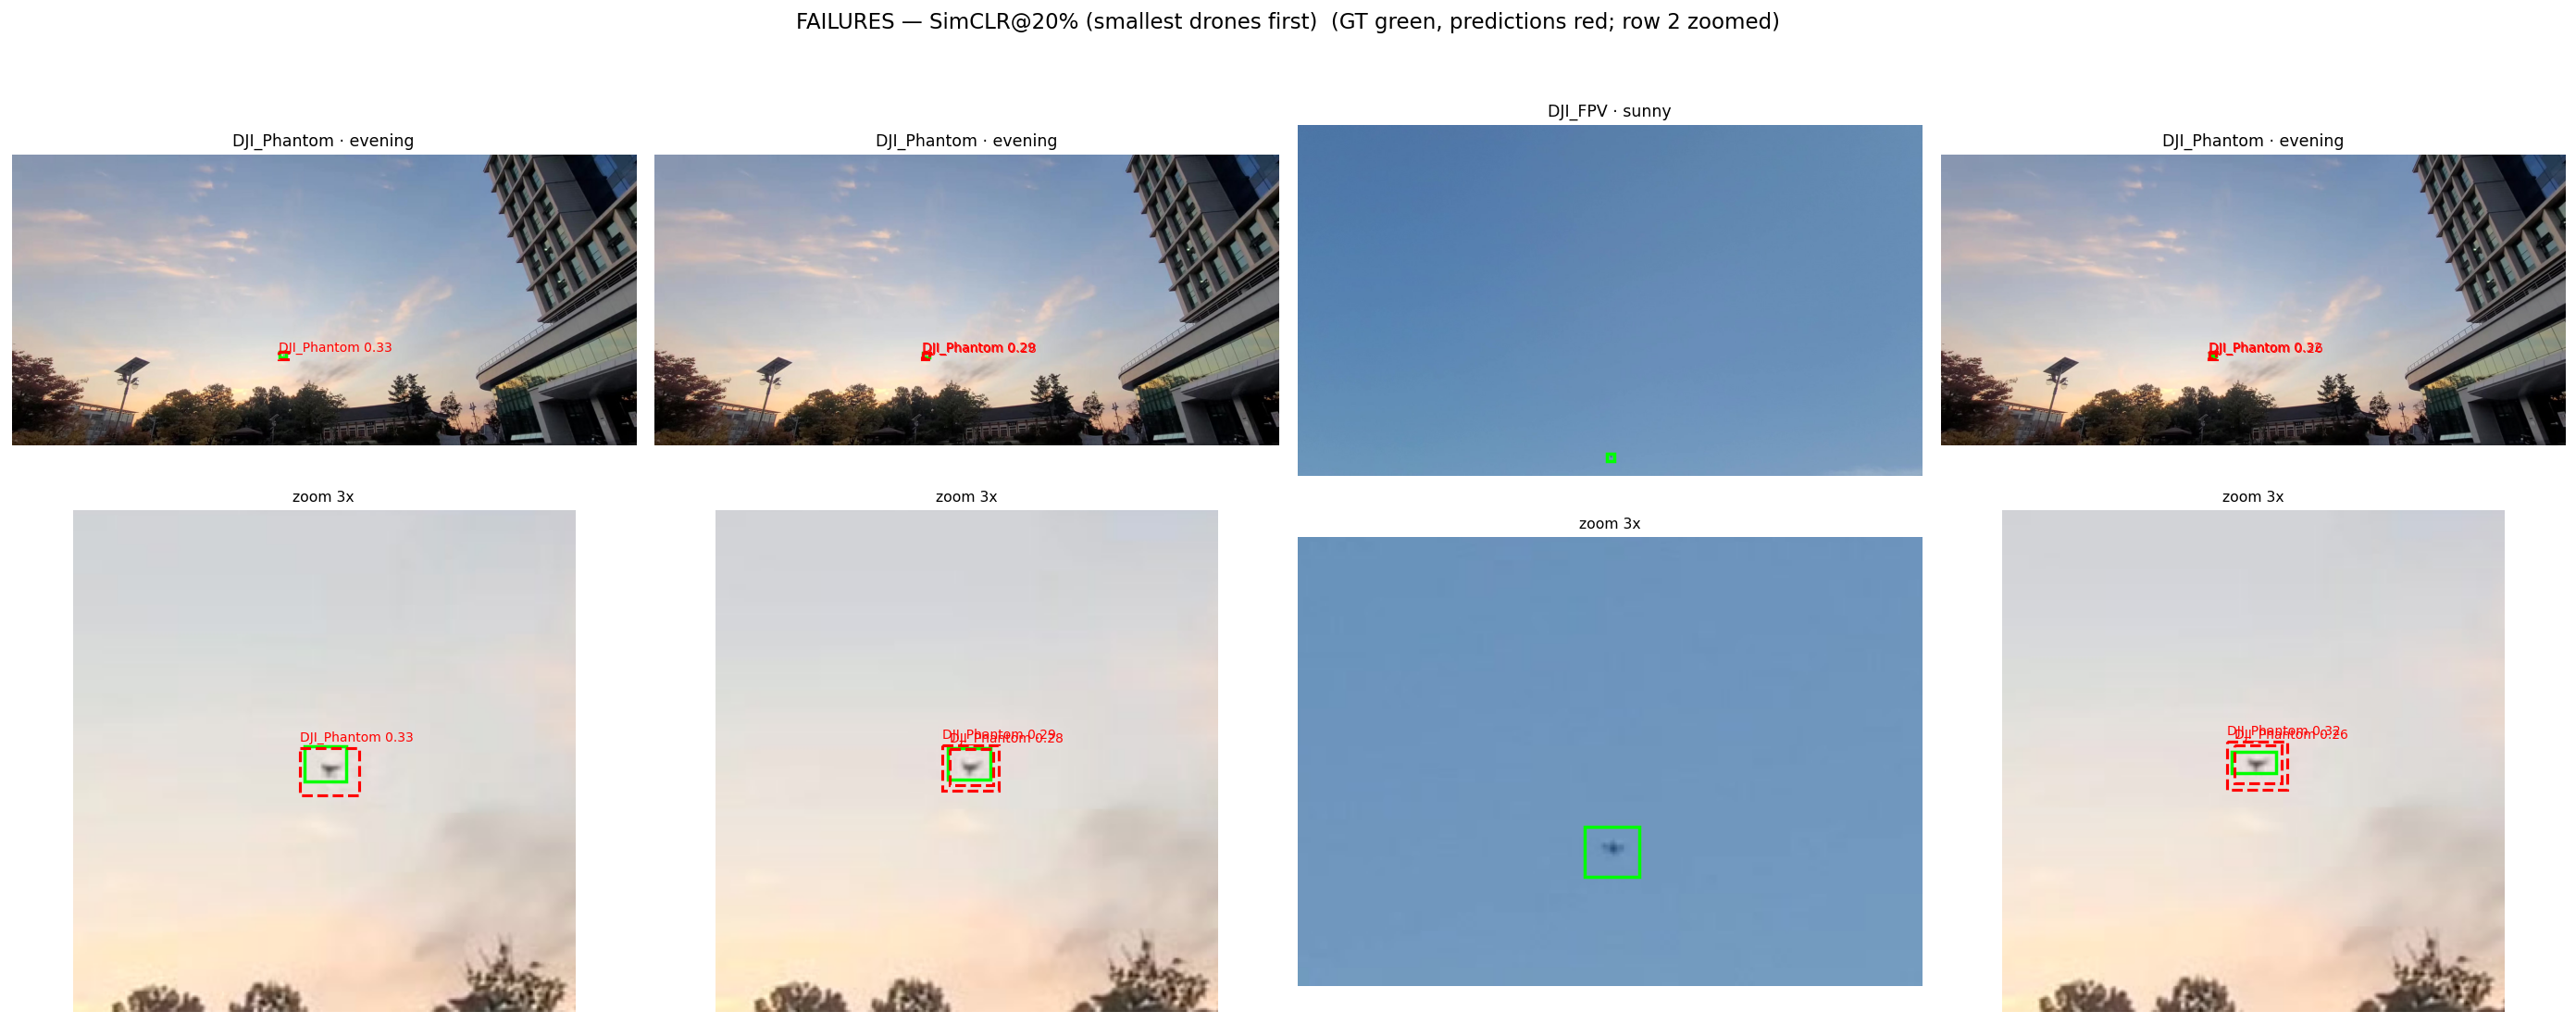

In [14]:
def zoom_window(box, W, H, factor=3.0, min_side=90):
    x1, y1, x2, y2 = box
    cx, cy = (x1+x2)/2, (y1+y2)/2
    side = max(x2-x1, y2-y1, min_side) * factor
    return (int(max(0, cx-side/2)), int(max(0, cy-side/2)),
            int(min(W, cx+side/2)), int(min(H, cy+side/2)))

def draw(ax, im, gt, preds, off=(0, 0)):
    ox, oy = off
    ax.imshow(im); ax.set_axis_off()
    for g in gt:
        x1, y1, x2, y2 = g["box"]
        ax.add_patch(mpatches.Rectangle((x1-ox, y1-oy), x2-x1, y2-y1,
                                        fill=False, edgecolor="lime", lw=2))
    for p in preds:
        x1, y1, x2, y2 = p["box"]
        ax.add_patch(mpatches.Rectangle((x1-ox, y1-oy), x2-x1, y2-y1, fill=False,
                                        edgecolor="red", lw=1.8, linestyle="--"))
        ax.text(x1-ox, y1-oy-4, f"{CLASS_NAMES[p['cls']]} {p['score']:.2f}",
                color="red", fontsize=8)

def panel(frame, title, n=4):
    frame = frame.head(n)
    if frame.empty:
        print(title, "- no cases"); return
    fig, axes = plt.subplots(2, len(frame), figsize=(5.6*len(frame), 9))
    axes = np.atleast_2d(axes)
    for col, (_, r) in enumerate(frame.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
        gt, preds = gt_for(r.image), pred_cache[Path(r.image).name]
        draw(axes[0, col], im, gt, preds)
        axes[0, col].set_title(f"{r.class_name} · {r.scenario}", fontsize=10)
        anchor = gt[0]["box"] if gt else (preds[0]["box"] if preds else [0, 0, W, H])
        zx1, zy1, zx2, zy2 = zoom_window(anchor, W, H)
        draw(axes[1, col], im[zy1:zy2, zx1:zx2], gt, preds, off=(zx1, zy1))
        axes[1, col].set_title("zoom 3x", fontsize=9)
    fig.suptitle(title + "  (GT green, predictions red; row 2 zoomed)")
    plt.tight_layout(); plt.show()

ok = err[(err.fn == 0) & (err.fp == 0)]
panel(ok.sample(min(4, len(ok)), random_state=PARTB_SEED), "SUCCESSES — SimCLR@20%")
bad = err[(err.fn > 0) | (err.fp > 0)].sort_values("side")
panel(bad, "FAILURES — SimCLR@20% (smallest drones first)")


## 11. Bonus — Explainability: EigenCAM + ScoreCAM Grid
Two **gradient-free** CAMs on the fine-tuned SimCLR detector, answering different questions:

- **EigenCAM** — the first principal component of the Detect head's input feature maps
  (all three neck scales, combined). It shows *what dominates the backbone's
  representation* — class-agnostic, one forward pass. Implemented from first principles
  (hook + SVD), the Part A recipe.
- **ScoreCAM** — activation channels of the highest-resolution neck scale, each used to
  **mask the input image**; the confidence the detector still assigns under each mask
  becomes that channel's weight. It shows *which activations causally support the
  detection*. Exhaustive ScoreCAM needs one forward per channel, so the standard **top-K
  approximation** is used (K channels by activation energy — documented, K=24).

Reading the grid: on TPs both maps should agree on the drone; on FNs, EigenCAM heat without
a detection = *represented but rejected by the head*, no heat = *never represented* — the
same diagnostic language as Part A, now applied to what SimCLR's distilled features attend
to.

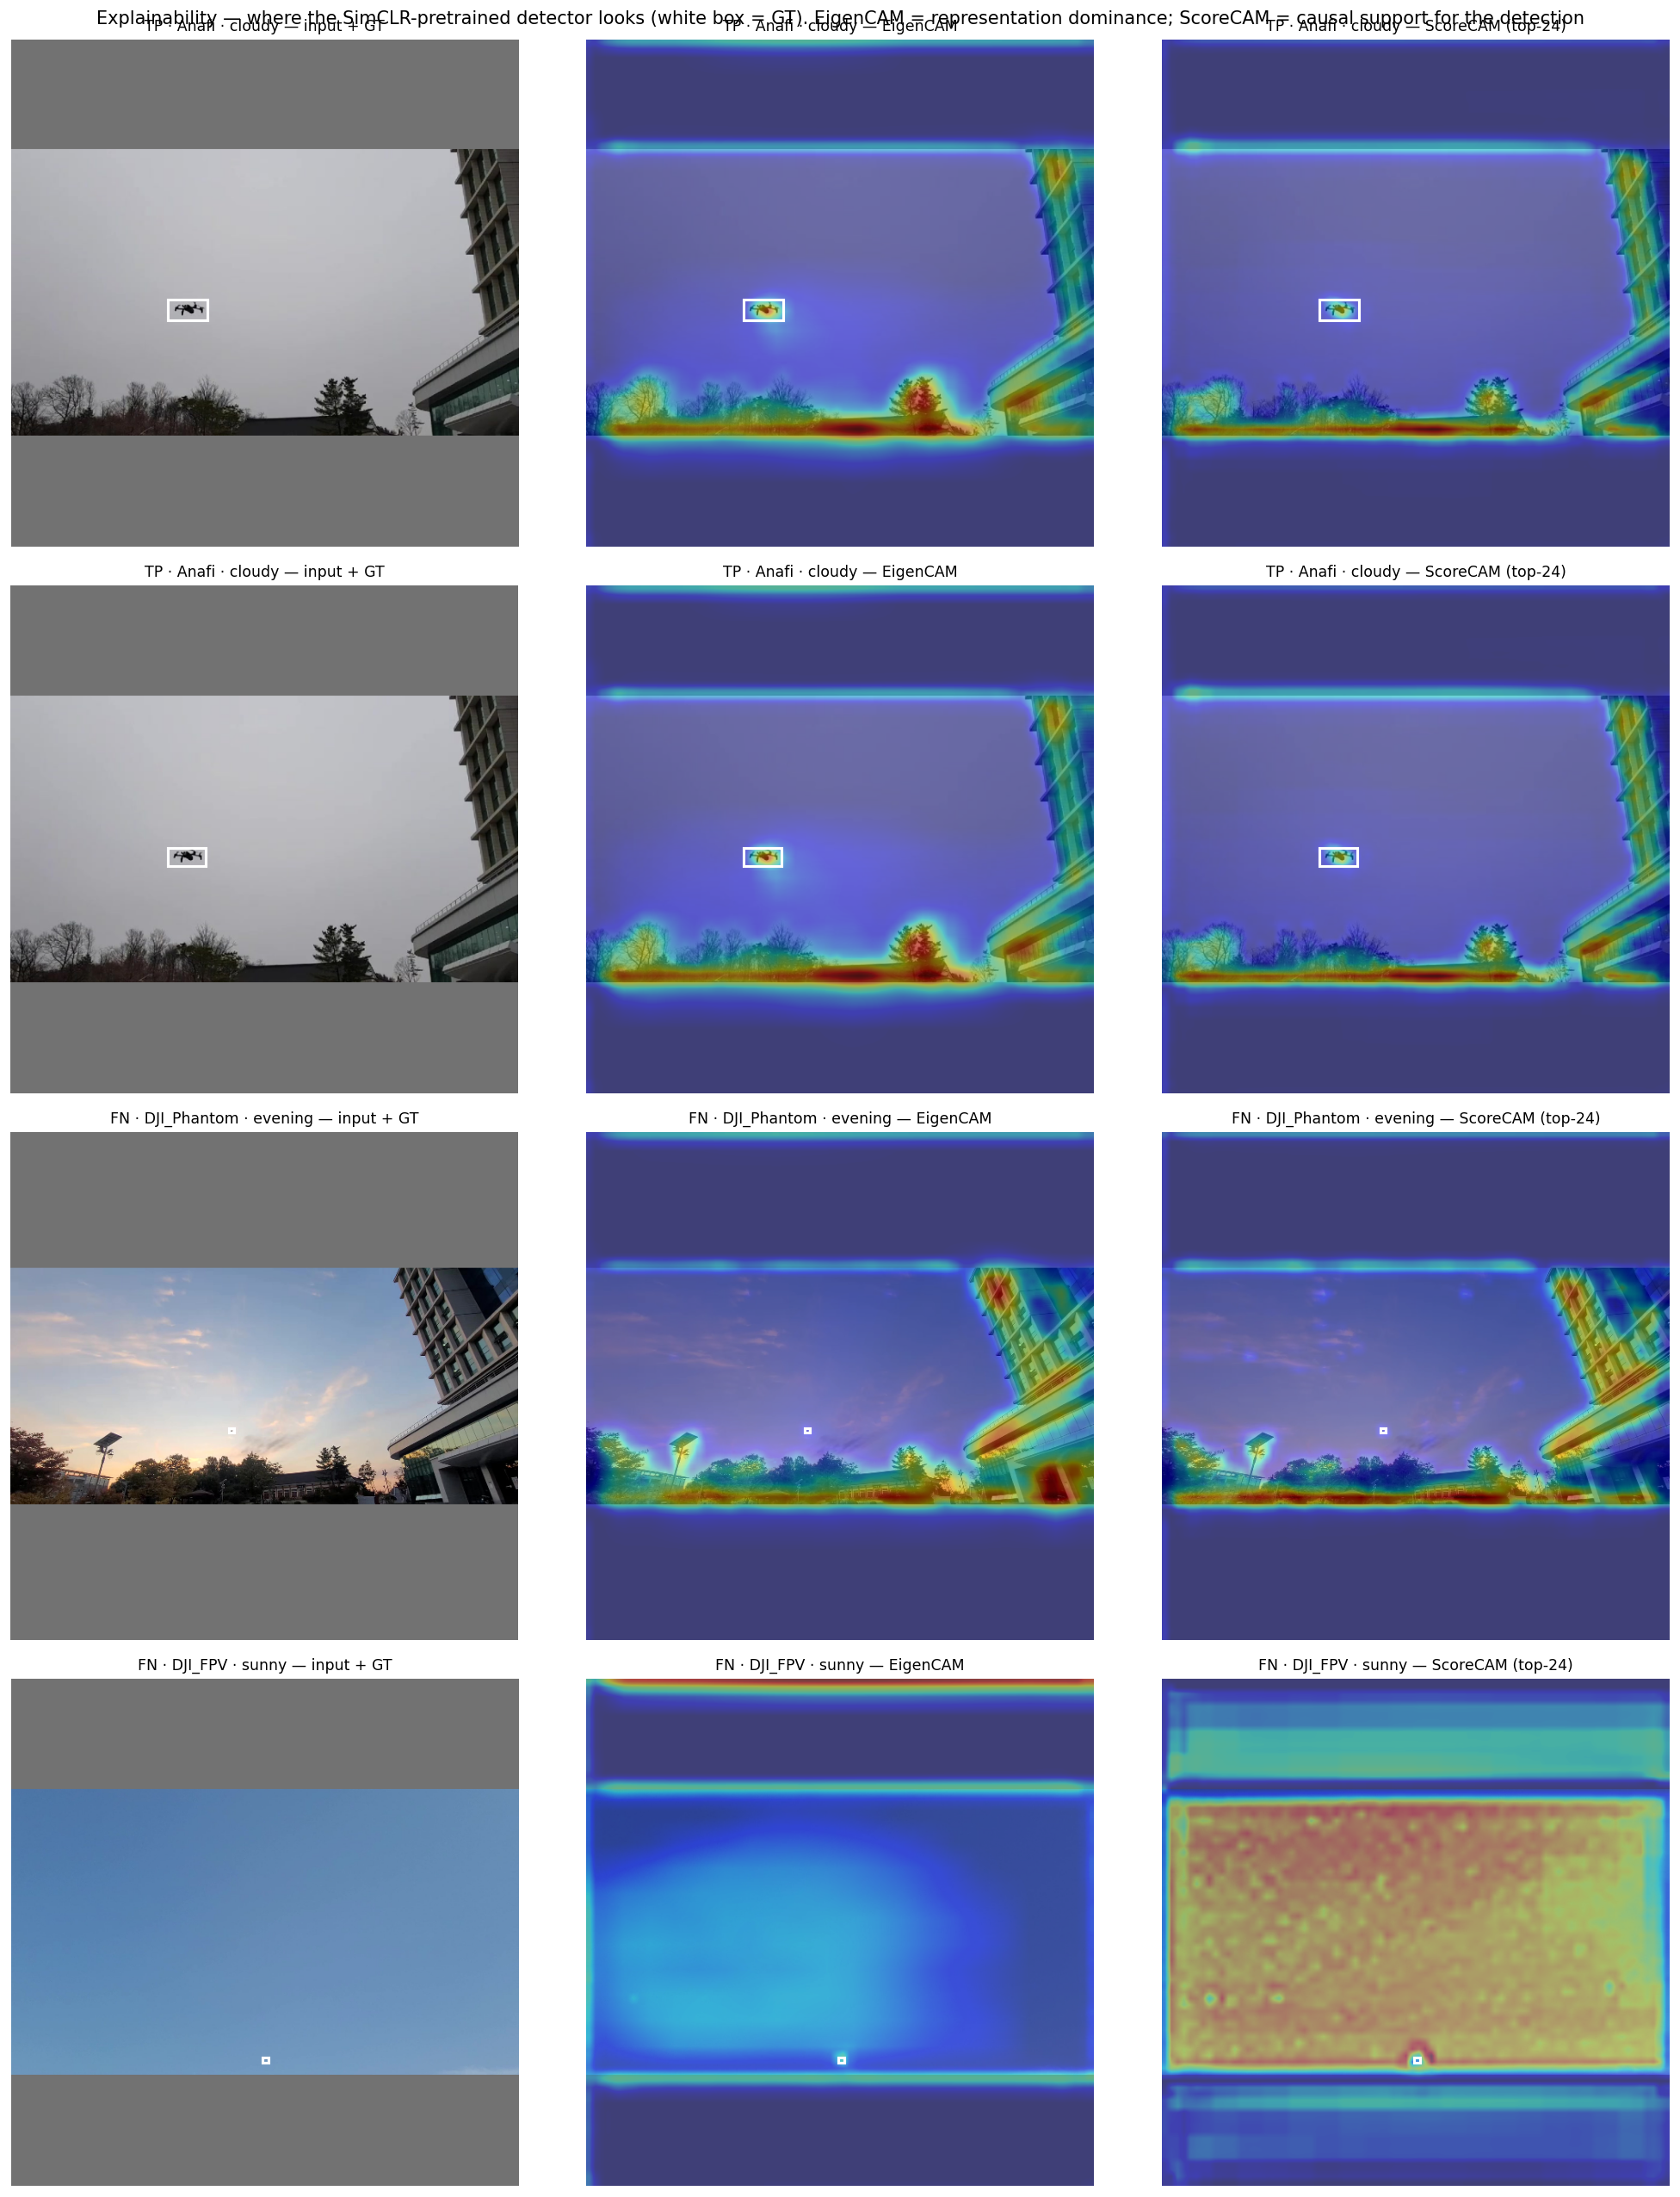

Reading for §7.1-style commentary: does ScoreCAM heat sit tighter on the drone than EigenCAM's (causal vs variance)? On the FN rows: heat present = represented-but-rejected (head/confidence issue); heat absent = never represented (feature issue).


In [15]:
import torch.nn.functional as Fnn
from ultralytics.data.augment import LetterBox

SCORECAM_TOPK = 24
core = simclr_best.model
core.eval()
detect_head = core.model[-1]
_feats = {}
_hook = detect_head.register_forward_pre_hook(
    lambda m, args: _feats.__setitem__("p", [f.detach().float().cpu() for f in args[0]]))
_lb = LetterBox((IMGSZ, IMGSZ))
_dev = next(core.parameters()).device
_dtype = next(core.parameters()).dtype

def _prep(img_path):
    im0 = np.array(Image.open(img_path).convert("RGB"))
    H0, W0 = im0.shape[:2]
    lbim = _lb(image=im0)
    r_ = min(IMGSZ / W0, IMGSZ / H0)
    dw, dh = (IMGSZ - W0 * r_) / 2, (IMGSZ - H0 * r_) / 2
    gt_boxes = [[b * r_ + (dw if k % 2 == 0 else dh) for k, b in enumerate(g["box"])]
                for g in gt_for(img_path)]
    gt_cls = [g["cls"] for g in gt_for(img_path)]
    return lbim, gt_boxes, gt_cls

def eigencam(lbim):
    t = torch.from_numpy(lbim.copy()).permute(2, 0, 1)[None].to(_dev, _dtype) / 255
    with torch.no_grad():
        core(t)
    cams = []
    for f in _feats["p"]:
        Cc, Hf, Wf = f.shape[1:]
        A = f[0].reshape(Cc, -1).T
        A = A - A.mean(0, keepdim=True)
        Vh = torch.linalg.svd(A, full_matrices=False).Vh
        proj = (A @ Vh[0]).reshape(Hf, Wf)
        if proj.max() < -proj.min():
            proj = -proj
        cam = Fnn.interpolate(torch.relu(proj)[None, None], size=(IMGSZ, IMGSZ),
                              mode="bilinear", align_corners=False)[0, 0]
        cams.append(cam / (cam.max() + 1e-9))
    return torch.stack(cams).mean(0).numpy(), [f.clone() for f in _feats["p"]]

def scorecam(lbim, feats, gt_cls, topk=SCORECAM_TOPK):
    A = feats[0][0]                                # P3: highest-resolution scale (C,H,W)
    energy = A.clamp(min=0).mean(dim=(1, 2))
    idx = energy.topk(min(topk, A.shape[0])).indices
    scores = []
    for k in idx:
        m = A[k]
        m = (m - m.min()) / (m.max() - m.min() + 1e-9)
        mask = Fnn.interpolate(m[None, None], size=(IMGSZ, IMGSZ),
                               mode="bilinear", align_corners=False)[0, 0].numpy()
        masked = (lbim.astype(np.float32) * mask[..., None]).astype(np.uint8)
        r = simclr_best.predict(masked, imgsz=IMGSZ, conf=0.01, device=DEVICE,
                                verbose=False)[0]
        s = 0.0
        if r.boxes is not None and len(r.boxes):
            confs = r.boxes.conf.cpu().numpy()
            clss = r.boxes.cls.cpu().numpy().astype(int)
            match_ = confs[np.isin(clss, gt_cls)] if gt_cls else confs
            s = float(match_.max()) if len(match_) else float(confs.max()) * 0.5
        scores.append(s)
    w = torch.softmax(torch.tensor(scores), dim=0)
    cam = torch.relu((w[:, None, None] * A[idx]).sum(0))
    cam = Fnn.interpolate(cam[None, None], size=(IMGSZ, IMGSZ),
                          mode="bilinear", align_corners=False)[0, 0]
    return (cam / (cam.max() + 1e-9)).numpy()

tp_pick = err[(err.fn == 0) & (err.fp == 0)].head(2)
fn_pick = err[err.fn > 0].sort_values("side").head(2)
panels = [("TP", r) for _, r in tp_pick.iterrows()] + [("FN", r) for _, r in fn_pick.iterrows()]
if panels:
    fig, axes = plt.subplots(len(panels), 3, figsize=(16.5, 5.2 * len(panels)))
    axes = np.atleast_2d(axes)
    for row, (tag, r) in enumerate(panels):
        lbim, gtb, gtc = _prep(r.image)
        eig, feats = eigencam(lbim)
        sco = scorecam(lbim, feats, gtc)
        for col, (overlay, name) in enumerate(
                [(None, "input + GT"), (eig, "EigenCAM"), (sco, f"ScoreCAM (top-{SCORECAM_TOPK})")]):
            ax = axes[row, col]; ax.imshow(lbim); ax.set_axis_off()
            if overlay is not None:
                ax.imshow(overlay, cmap="jet", alpha=0.45)
            for x1, y1, x2, y2 in gtb:
                ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                                                edgecolor="white", lw=1.8))
            ax.set_title(f"{tag} · {r.class_name} · {r.scenario} — {name}", fontsize=10)
    fig.suptitle("Explainability — where the SimCLR-pretrained detector looks "
                 "(white box = GT). EigenCAM = representation dominance; "
                 "ScoreCAM = causal support for the detection", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{WORK_ROOT}/simclr_explainability_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
_hook.remove()
print("Reading for §7.1-style commentary: does ScoreCAM heat sit tighter on the drone than "
      "EigenCAM's (causal vs variance)? On the FN rows: heat present = represented-but-"
      "rejected (head/confidence issue); heat absent = never represented (feature issue).")


## 12. Export & Hand-off
| Artifact | Path |
|---|---|
| Fine-tuned detectors | `checkpoints/partB_{ijepa,random,coco}_rho20_best.pt` |
| Per-run metrics (reused by 1b/2b/4b) | `partB_downstream/{ijepa,random,coco}.json` (+ `reference_100pct.json`) |
| Curves / PR / errors / XAI | `simclr20_curves.png`, evaluation PR plot, `simclr20_test_errors.csv`, `simclr_explainability_grid.png` |

Per the §4.2 note: once 1b/2b/4b are done, the **method ranking table** (Section 9) picks the
winner, whose `partB_<method>_rho20_best.pt` is published as a Kaggle dataset for the
tracking notebook.

In [16]:
manifest = {"notebook": "partB-01b-simclr-detect", "rho": RHO, "seed": PARTB_SEED,
            "protocol": {"epochs": EPOCHS, "imgsz": IMGSZ, "batch": BATCH,
                         "patience": PATIENCE, "optimizer": OPTIMIZER, "lr0": LR0,
                         "close_mosaic": CLOSE_MOSAIC, "fliplr": FLIPLR},
            "runs": {k: v["checkpoint"] for k, v in results.items()},
            "test_mAP50_95": {k: v["test_mAP50_95"] for k, v in results.items()}}
Path(f"{WORK_ROOT}/partB_01b_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))
for p in Path(CKPT_OUT).glob("partB_*"):
    print(f"[OK] {p.name:<38} {p.stat().st_size/1e6:>7.1f} MB")


{
  "notebook": "partB-01b-simclr-detect",
  "rho": 0.2,
  "seed": 445,
  "protocol": {
    "epochs": 50,
    "imgsz": 640,
    "batch": 16,
    "patience": 25,
    "optimizer": "auto",
    "lr0": 0.01,
    "close_mosaic": 10,
    "fliplr": 0.5
  },
  "runs": {
    "simclr": "/kaggle/working/checkpoints/partB_simclr_rho20_best.pt"
  },
  "test_mAP50_95": {
    "simclr": 0.6041
  }
}
[OK] partB_simclr_rho20_best.pt                20.3 MB


## 13. Pre-Commit Checklist 
- [ ] §3 printed the **partition fingerprint match** against 1a — the assertion must pass
- [ ] Subset counts + per-class instances printed; disjointness `[OK]`
- [ ] **Mapping report table** rendered with the SimCLR/random split and both checksum proofs
- [ ] Demo inference, training curves, PR curve, val + test metrics visible
- [ ] §9 four-way comparison table + deltas + **both footnotes** + the SSL ranking printed
- [ ] The ranking names a Task-1 winner, and it is the initialisation the bonus swept
- [ ] Explainability grid (§11) rendered; success/failure panels visible
- [ ] Checkpoints + `partB_downstream/simclr.json` listed `[OK]`; committed Public
